<a href="https://colab.research.google.com/github/hocinemahni/mc_arc/blob/main/orbit_aging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

'orbit_mode_ex_with_stat_v2.png'

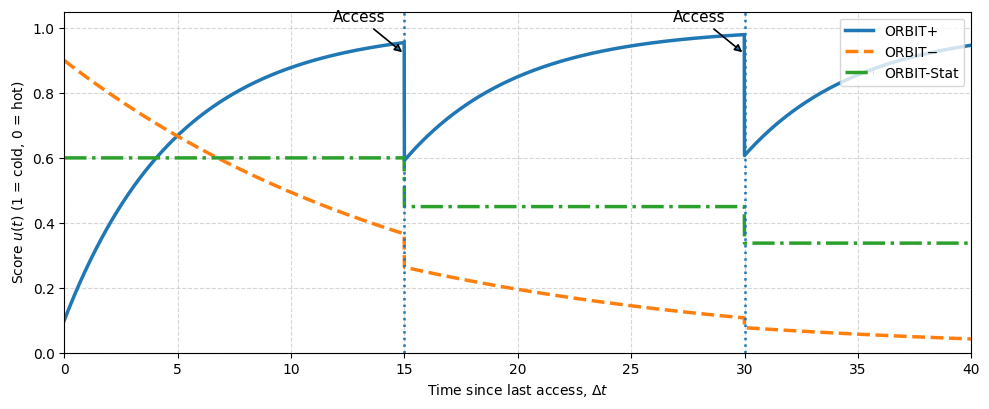

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Configuration (shape matches ORBIT equations) ---
t = np.linspace(0, 40, 4001)
access_times = [15, 30]

# Aging rates (picked to make shapes clearly distinct)
eps_plus = 0.20     # Orbit+ pulls u toward 1 (forgetting)
eps_minus = 0.06    # Orbit- pushes u down (protection)
# Orbit-Stat: no time aging

# Access reinforcement (multiplicative drops at access instants)
drop_plus = 0.62
drop_minus = 0.72
drop_stat = 0.75

u0_plus, u0_minus, u0_stat = 0.10, 0.90, 0.60

def orbit_plus(t):
    u = np.empty_like(t)
    u_cur, t_prev, i0 = u0_plus, 0.0, 0
    for a in access_times + [t[-1] + 1]:
        i1 = np.searchsorted(t, a, side="left")
        tt = t[i0:i1]
        u[i0:i1] = 1.0 - (1.0 - u_cur) * np.exp(-eps_plus * (tt - t_prev))
        if a in access_times:
            u_at = 1.0 - (1.0 - u_cur) * np.exp(-eps_plus * (a - t_prev))
            u_cur = u_at * drop_plus
            t_prev, i0 = a, i1
        else:
            break
    return u

def orbit_minus(t):
    u = np.empty_like(t)
    u_cur, t_prev, i0 = u0_minus, 0.0, 0
    for a in access_times + [t[-1] + 1]:
        i1 = np.searchsorted(t, a, side="left")
        tt = t[i0:i1]
        u[i0:i1] = u_cur * np.exp(-eps_minus * (tt - t_prev))
        if a in access_times:
            u_at = u_cur * np.exp(-eps_minus * (a - t_prev))
            u_cur = u_at * drop_minus
            t_prev, i0 = a, i1
        else:
            break
    return u

def orbit_stat(t):
    u = np.empty_like(t)
    u_cur, i0 = u0_stat, 0
    for a in access_times + [t[-1] + 1]:
        i1 = np.searchsorted(t, a, side="left")
        u[i0:i1] = u_cur
        if a in access_times:
            u_cur = u_cur * drop_stat
            i0 = i1
        else:
            break
    return u

u_p = orbit_plus(t)
u_m = orbit_minus(t)
u_s = orbit_stat(t)

# --- Plot (clean layout, no overlapping annotations) ---
plt.figure(figsize=(10, 4.2))
plt.plot(t, u_p, linewidth=2.5, label="ORBIT+")
plt.plot(t, u_m, "--", linewidth=2.5, label="ORBIT−")
plt.plot(t, u_s, "-.", linewidth=2.5, label="ORBIT-Stat")

for at in access_times:
    plt.axvline(at, linestyle=":", linewidth=1.8)
    plt.annotate(
        "Access",
        xy=(at, 0.92),
        xytext=(at - 2.0, 1.02),
        arrowprops=dict(arrowstyle="-|>", lw=1.2),
        fontsize=11,
        ha="center"
    )

plt.ylim(0, 1.05)
plt.xlim(0, 40)
plt.xlabel(r"Time since last access, $\Delta t$")
plt.ylabel(r"Score $u(t)$ (1 = cold, 0 = hot)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()

out_path = "orbit_mode_ex_with_stat_v2.png"
plt.savefig(out_path, dpi=220)
out_path


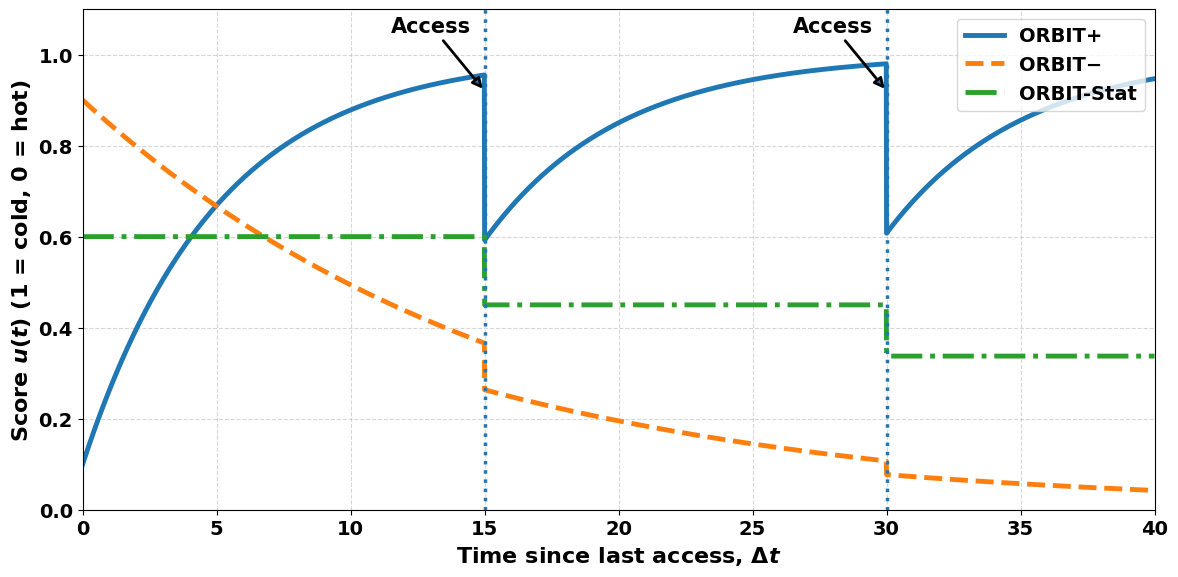

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PARAMÈTRES GLOBAUX : ---
plt.rcParams.update({
    'font.weight': 'bold',
    'font.size': 14,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold'
})

# --- Configuration (shape matches ORBIT equations) ---
t = np.linspace(0, 40, 4001)
access_times = [15, 30]

# Aging rates (picked to make shapes clearly distinct)
eps_plus = 0.20     # Orbit+ pulls u toward 1 (forgetting)
eps_minus = 0.06    # Orbit- pushes u down (protection)
# Orbit-Stat: no time aging

# Access reinforcement (multiplicative drops at access instants)
drop_plus = 0.62
drop_minus = 0.72
drop_stat = 0.75

u0_plus, u0_minus, u0_stat = 0.10, 0.90, 0.60

def orbit_plus(t):
    u = np.empty_like(t)
    u_cur, t_prev, i0 = u0_plus, 0.0, 0
    for a in access_times + [t[-1] + 1]:
        i1 = np.searchsorted(t, a, side="left")
        tt = t[i0:i1]
        u[i0:i1] = 1.0 - (1.0 - u_cur) * np.exp(-eps_plus * (tt - t_prev))
        if a in access_times:
            u_at = 1.0 - (1.0 - u_cur) * np.exp(-eps_plus * (a - t_prev))
            u_cur = u_at * drop_plus
            t_prev, i0 = a, i1
        else:
            break
    return u

def orbit_minus(t):
    u = np.empty_like(t)
    u_cur, t_prev, i0 = u0_minus, 0.0, 0
    for a in access_times + [t[-1] + 1]:
        i1 = np.searchsorted(t, a, side="left")
        tt = t[i0:i1]
        u[i0:i1] = u_cur * np.exp(-eps_minus * (tt - t_prev))
        if a in access_times:
            u_at = u_cur * np.exp(-eps_minus * (a - t_prev))
            u_cur = u_at * drop_minus
            t_prev, i0 = a, i1
        else:
            break
    return u

def orbit_stat(t):
    u = np.empty_like(t)
    u_cur, i0 = u0_stat, 0
    for a in access_times + [t[-1] + 1]:
        i1 = np.searchsorted(t, a, side="left")
        u[i0:i1] = u_cur
        if a in access_times:
            u_cur = u_cur * drop_stat
            i0 = i1
        else:
            break
    return u

u_p = orbit_plus(t)
u_m = orbit_minus(t)
u_s = orbit_stat(t)


fig, ax = plt.subplots(figsize=(12, 6))


ax.plot(t, u_p, linewidth=3.5, label="ORBIT+")
ax.plot(t, u_m, "--", linewidth=3.5, label="ORBIT−")
ax.plot(t, u_s, "-.", linewidth=3.5, label="ORBIT-Stat")

for at in access_times:
    ax.axvline(at, linestyle=":", linewidth=2.5)
    ax.annotate(
        "Access",
        xy=(at, 0.92),
        xytext=(at - 2.0, 1.05),
        arrowprops=dict(arrowstyle="-|>", lw=2.0),
        fontsize=15,
        fontweight='bold',
        ha="center"
    )

ax.set_ylim(0, 1.1)
ax.set_xlim(0, 40)

# Axes X et Y
ax.set_xlabel(r"Time since last access, $\Delta t$", fontsize=16, fontweight='bold')
ax.set_ylabel(r"Score $u(t)$ (1 = cold, 0 = hot)", fontsize=16, fontweight='bold')

# graduations (ticks)
ax.tick_params(axis='both', labelsize=14)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

ax.grid(True, linestyle="--", alpha=0.5)

# Légende
ax.legend(loc="upper right", frameon=True, prop={'weight': 'bold', 'size': 14})

plt.tight_layout()

out_path = "orbit_mode_ex_with_stat_v2_bold.png"
plt.savefig(out_path, dpi=220)
plt.show()